## Import Dependencies

In [1]:
import os
import random
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse, scatter
from torch_geometric.nn import global_mean_pool, global_max_pool, Set2Set
from torch_geometric.nn import NNConv, CGConv, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN
from pymatgen.util import coord as puc
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms
from pymatgen.analysis.graphs import StructureGraph

from graphy_gnn_copy import get_nodes, get_edges_and_features, get_globals, gnn_graphy
from graphy_cvae import get_target_tensor, cvae_graphy, fast_cvae_graphy
from graphy_cvae import get_pristine_edges, get_pristine_nodes, get_mask

import build_graphs

from structure_manipulation import clean_defective_manipulation, full_defective_manipulation
from structure_manipulation import cloud_manipulation, visualize_structure

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Prep

In [2]:
# The whole dataset
comb_df = pd.read_csv(f"Final_Dataset/combined/combined_data.csv")
# sample_df = comb_df.sample(10, random_state=42)

# Sample row
a_row = comb_df.head() # .iloc[np.random.randint(0, len(comb_df))]

samp_for_gnn = build_graphs.fast_graphy(a_row, for_model='gnn')
samp_for_cvae = build_graphs.fast_graphy(a_row, for_model='cvae')


/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 31 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


/home/amutua/Msproject1/build_graphs.py:577: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x          =torch.tensor(for_encoder[0], dtype=torch.float),


In [3]:
# Create class weight loss

def get_weights(df):
    
    unique_dm = df["dataset_material"].unique()

    ref_structures_len = [len(Structure.from_file(f"Final_Dataset/ref_cifs/{material}.cif")) for material in unique_dm]

    total_ps = 0
    total_vacs = 0
    total_subs = 0

    for ref_num, material in zip(ref_structures_len, unique_dm):
        
        material_df = df[df["dataset_material"] == material]

        num_vacs = material_df["vacancy_sites"].sum()
        num_subs = material_df["substitution_sites"].sum()


        total_pristine_sites = (ref_num * len(material_df)) - (num_vacs + num_subs)

        total_ps += total_pristine_sites
        total_vacs += num_vacs
        total_subs += num_subs

    tots = total_ps + total_vacs + total_subs
    site_weight = [(tots/(total_ps * 3)), (tots/(total_vacs*3)), (tots/(total_subs * 3))]
    

    return site_weight

sample_df = comb_df[(comb_df['dataset_material'] == "high_MoS2") | (comb_df['dataset_material'] == "low_MoS2")]

sample_weights = get_weights(sample_df)
print(sample_weights)

[np.float64(0.34012517431216915), np.float64(33.364019448946515), np.float64(33.407335280753)]


/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


## Implimentation on a dataset

In [6]:
comb_df = comb_df[comb_df["defect_sites"] != 1]

# sample_df = comb_df[comb_df["dataset_material"] == "high_MoS2"]
# sample_df = comb_df[(comb_df["dataset_material"] != "low_MoS2") & (comb_df["dataset_material"] != "low_WSe2")]
# sample_df = comb_df[(comb_df['dataset_material'] == "high_MoS2") | (comb_df['dataset_material'] == "low_MoS2")]
focus_materials = ["high_BN", "high_GaSe", "high_InSe", "high_P"]
sample_df = comb_df[comb_df['dataset_material'].isin(focus_materials)]

# _, sample_df= train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)

SAMPLE_WEIGHTS = get_weights(sample_df)

sample_train, sample_val = train_test_split(sample_df, test_size=0.2, stratify=sample_df["strata"], random_state=42)

sample_train_graphs = build_graphs.fast_graphy(sample_train, 'cvae')
sample_val_graphs = build_graphs.fast_graphy(sample_val, 'cvae')

# Or just load the whole dataset
# full_train_graphs = torch.load("Final_Dataset/cvae graphs/cvae_train_graphs.pt", weights_only=False)
# full_val_graphs = torch.load("Final_Dataset/cvae graphs/cvae_val_graphs.pt", weights_only=False)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 23 fractional coordi

## More Data Manipulations

In [7]:
def add_bond_batch(graph):
    for data in graph:
        bond_batch = torch.zeros((1, data.edge_index.shape[1]))
        data.bond_batch = bond_batch.squeeze(0).to(dtype=torch.long)

    return graph

# full_train_graphs = add_bond_batch(full_train_graphs)
# full_val_graphs = add_bond_batch(full_val_graphs)

sample_train_graphs = add_bond_batch(sample_train_graphs)
sample_val_graphs = add_bond_batch(sample_val_graphs)

In [8]:
# ========================
# SCALE THE GRAPHS
# ========================

class FeatureScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, graphs, attr):
        all_vals = torch.cat([getattr(g, attr) for g in graphs], dim=0)
        self.mean = all_vals.mean(dim=0, keepdim=True)
        self.std = all_vals.std(dim=0, keepdim=True) + 1e-8
        return self

    def transform(self, graphs, attr):
        for g in graphs:
            setattr(g, attr, (getattr(g, attr) - self.mean) / self.std)
        return graphs

def scale_graphs(train_graphs, val_graphs): 

    x_scaler = FeatureScaler().fit(train_graphs, "x")
    edge_scaler = FeatureScaler().fit(train_graphs, "edge_attr")
    u_scaler = FeatureScaler().fit(train_graphs, "u")

    new_graphs = []

    for split in [train_graphs, val_graphs]:
        split = x_scaler.transform(split, "x")
        split = edge_scaler.transform(split, "edge_attr")
        split = u_scaler.transform(split, "u")
        new_graphs.append(split)

    new_train_graphs = new_graphs[0]
    new_val_graphs = new_graphs[1]

    return new_train_graphs, new_val_graphs

# new_full_train_graphs, new_full_val_graphs = scale_graphs(full_train_graphs, full_val_graphs)
new_sample_train_graphs, new_sample_val_graphs = scale_graphs(sample_train_graphs, sample_val_graphs)

Before Sampling
Counts per bin: [ 99 267 325 361 271 135  66  41  20   6   4   5]
Bin boundaries: [0.02805   0.237625  0.4472    0.656775  0.86635   1.0759249 1.2854999
 1.495075  1.7046499 1.9142249 2.1237998 2.333375  2.54295  ]


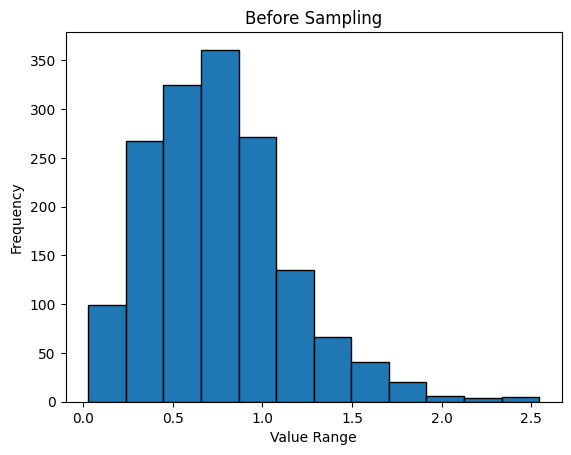

In [9]:
# Sample_train_graphs

print("Before Sampling")

train_targets = [new_sample_train_graphs[i].bgv.numpy()[0] for i in range(len(new_sample_train_graphs))]

hist, bin_edges = np.histogram(train_targets, bins=12)

# frequency per bin
freq = hist + 1e-6

# inverse frequency weights
bin_weights = 1.0 / freq


print("Counts per bin:", hist)
print("Bin boundaries:", bin_edges)

# 2. Graphically plot the computed data
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
plt.title("Before Sampling")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

After Sampling


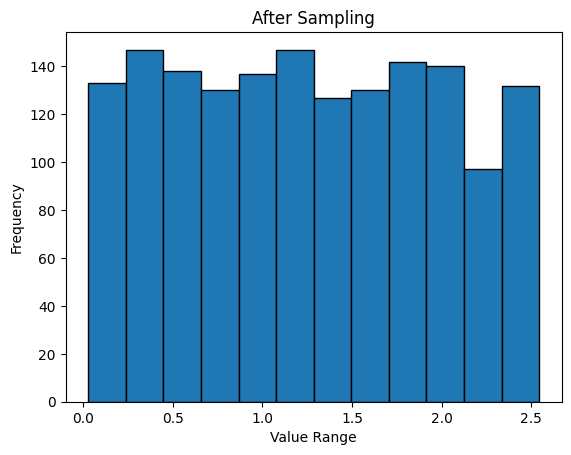

In [10]:
# Map each sample to a weight

bin_idx = np.digitize(train_targets, bin_edges[:-1])

sample_weights1 = bin_weights[bin_idx - 1]

from torch.utils.data import WeightedRandomSampler

sampler1 = WeightedRandomSampler(
    sample_weights1,
    len(sample_weights1),
    replacement=True
)

# Create data loaders
BATCH_SIZE = 1

# full_train_loader = DataLoader(new_full_train_graphs, batch_size=BATCH_SIZE, sampler=sampler1) 
# full_val_loader   = DataLoader(new_full_val_graphs, batch_size=BATCH_SIZE, shuffle=False)

sample_train_loader = DataLoader(new_sample_train_graphs, batch_size=BATCH_SIZE, sampler=sampler1) 
sample_val_loader   = DataLoader(new_sample_val_graphs, batch_size=BATCH_SIZE, shuffle=False)

print("After Sampling")

new_targets1 = [i.bgv.numpy()[0] for i in sample_train_loader]

hist1, bin_edges1 = np.histogram(new_targets1, bins=12)

plt.bar(bin_edges1[:-1], hist1, width=np.diff(bin_edges1), edgecolor="black", align="edge")
plt.title("After Sampling")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

In [11]:
sample_train_loader = DataLoader(new_sample_train_graphs, batch_size=BATCH_SIZE, shuffle=True) 
sample_val_loader   = DataLoader(new_sample_val_graphs, batch_size=BATCH_SIZE, shuffle=False)

# sample_0 = full_train_loader.dataset[0]
sample_0 = sample_train_loader.dataset[0]

ENCODER_X_DIM     = sample_0.x.shape[1] 
ENCODER_EDGE_DIM   = sample_0.edge_attr.shape[1] 
ENCODER_U_DIM      = sample_0.u.shape[1] 

HIDDEN_DIM = 256
LATENT_DIM = 32

print(f"Node dim: {ENCODER_X_DIM}\nEdge dim: {ENCODER_EDGE_DIM}\nU dim: {ENCODER_U_DIM}")

Node dim: 30
Edge dim: 14
U dim: 6


## Encoder

In [12]:

class ShiftedSoftplus(nn.Module):
    def __init__(self):
        super().__init__()
        self.sp = nn.Softplus()
        self.shift = nn.Parameter(torch.log(torch.tensor([2.])), requires_grad=False)

    def forward(self, x):
        return self.sp(x) - self.shift

In [13]:
# Encoder that looks like MEGNet

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()

        self.phi_e = nn.Sequential(
            nn.Linear(4 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_v = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_u = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

    def forward(self, x, edge_index, edge_attr, u, batch, bond_batch):
        row, col = edge_index

        u_per_edge = u[bond_batch]
        edge_attr = self.phi_e(torch.cat([x[row], x[col], edge_attr, u_per_edge], dim=1))

        agg_edges = scatter(edge_attr, row, dim=0, dim_size=x.size(0), reduce='mean')
        u_per_node = u[batch]
        x = self.phi_v(torch.cat([agg_edges, x, u_per_node], dim=1))

        edge_pooled = global_mean_pool(edge_attr, bond_batch)
        node_pooled = global_mean_pool(x, batch)

        u = self.phi_u(torch.cat([edge_pooled, node_pooled, u], dim=1))

        return x, edge_attr, u


class EncoderPart(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, embed_dim, num_blocks=2):
        super().__init__()
        self.nodes_mlp = nn.Sequential(
            nn.Linear(node_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.edge_attr_mlp = nn.Sequential(
            nn.Linear(edge_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.u_mlp = nn.Sequential(
            nn.Linear(u_dim + 1, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.blocks = nn.ModuleList([EncoderBlock(embed_dim) for _ in range(num_blocks)])

        self.set2set_x = Set2Set(embed_dim, processing_steps=3)
        self.set2set_edge_attr = Set2Set(embed_dim, processing_steps=3)

        self.readout = nn.Sequential(
            nn.Linear(5 * embed_dim, 4 * embed_dim), ShiftedSoftplus(),
            nn.Linear(4 * embed_dim, 3 * embed_dim), ShiftedSoftplus(),
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
        )

        self.mu_layer  = nn.Linear(2 * embed_dim, embed_dim)
        self.var_layer = nn.Linear(2 * embed_dim, embed_dim)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, bgv, bond_batch = (
            data.x, data.edge_index, data.edge_attr, data.batch, data.u, data.bgv, data.bond_batch
        )
        # encoder: x=26, edge_attr=14, u=6, bgv=1, 
        bgv = bgv.unsqueeze(0)

        x = self.nodes_mlp(x)
        edge_attr = self.edge_attr_mlp(edge_attr)
        u = self.u_mlp(torch.cat([u, bgv], dim=1))

        for block in self.blocks:
            x_new, edge_attr_new, u_new = block(x, edge_index, edge_attr, u, batch, bond_batch)
            # Residual connections: lets each block refine rather than overwrite,
            # and keeps gradients healthy through 3 stacked blocks
            x = x + x_new
            edge_attr = edge_attr + edge_attr_new
            u = u + u_new

        x_pool = self.set2set_x(x, batch)
        edge_pool = self.set2set_edge_attr(edge_attr, bond_batch)

        out = torch.cat([x_pool, edge_pool, u], dim=1)
        out = self.readout(out)
        
        mu  = self.mu_layer(out) 
        log_var = self.var_layer(out)
            
        return mu, log_var

the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for the_sample in sample_train_loader:
# for the_sample in full_train_loader:

    # Test encoder
    test_encoder = EncoderPart(ENCODER_X_DIM, ENCODER_EDGE_DIM, ENCODER_U_DIM, embed_dim=32, num_blocks=3)
    out_mu, out_log_var = test_encoder(the_sample)
    print("TESTING ENCODER\n")
    
    print("Mu shape:", out_mu.shape)
    
    print("Log var shape:", out_log_var.shape)

    break


TESTING ENCODER

Mu shape: torch.Size([1, 32])
Log var shape: torch.Size([1, 32])


## Decoder

### Target manipulations

In [14]:
def Zs_and_labels(mask, atomic_numbers=None, num_bool=None):
    # atomic_numbers is the atomic number representation of the sites 
    if atomic_numbers is not None: # Zs to labels
        bool_site = (mask == atomic_numbers[:, None]).int().argmax(dim=1)
        return bool_site.to(atomic_numbers.device)

    # num_bool is the 0(normal),1(vacancy),or 2(substitution) representation of the sites
    elif num_bool is not None: # labels to Zs
        the_true_z = mask[torch.arange(len(num_bool), device=num_bool.device), num_bool]
        return the_true_z.long()

sample_index = random.randint(0, len(sample_train_graphs)-1)
sample_0 = sample_train_graphs[sample_index]
    
print(f"Target using atomic numbers:\n\t {sample_0.y}")

y_num_bool = Zs_and_labels(sample_0.mask, atomic_numbers=sample_0.y) 
print(f"Target using 0,1,or 2:\n\t {y_num_bool}")

back_to_z = Zs_and_labels(sample_0.mask, num_bool=y_num_bool)
print(f"Target turned back to atomic numbers:\n\t {back_to_z}")

Target using atomic numbers:
	 tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 0, 5, 6, 5, 5, 6, 0, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 6, 7, 7, 7, 7, 7, 0, 7, 7, 0, 6, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 7, 7, 7, 7, 7, 7, 6, 7, 7, 7, 7, 7, 0, 7,
        7, 7, 7, 7, 7, 7, 7, 7])
Target using 0,1,or 2:
	 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Target turned back to atomic numbers:
	 tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 

In [15]:
def one_hot_and_labels(one_hot=None, labels=None):
    if one_hot is not None:
        return torch.argmax(one_hot, dim=-1)

    if labels is not None:
        return F.one_hot(labels,num_classes=3)

new_one_hot = one_hot_and_labels(labels=y_num_bool)
new_labels = one_hot_and_labels(one_hot=new_one_hot)

print(new_one_hot)
print(new_labels)


tensor([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 

In [16]:
# From logits to labels and one hot

def logits_manipulation(logits, one_hot=False):
    # Create labels
    labels = torch.argmax(logits, dim=-1)

    if one_hot:
        one_hot_tensor = F.one_hot(labels, num_classes=3)
        return one_hot_tensor
    else:
        return labels

example_logits = torch.randn([10,3])
print(logits_manipulation(example_logits))
print(logits_manipulation(example_logits, one_hot=True))

tensor([2, 2, 1, 1, 2, 0, 2, 1, 2, 0])
tensor([[0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0]])


In [17]:
def decode_structure(model_output, k=None, one_hot=False):
    """
    model_output: [num_sites, 3] raw logits (normal, vacancy, substitution)
    k: number of sites to mark as defective. If None, use the model's own
       soft count estimate (rounded).
    """
    probs = torch.softmax(model_output, dim=-1)
    prob_defective = 1.0 - probs[:, 0]

    if k is None:
        k = int(round(prob_defective.sum().item()))
        k = max(k, 1)  # avoid k=0 collapsing to literally nothing

    defective_indices = torch.topk(prob_defective, k=k).indices

    # among the chosen sites, pick vacancy vs substitution from their own 2-way split
    out_labels = torch.zeros(model_output.size(0), dtype=torch.long, device=model_output.device)
    sub_vs_vac = torch.argmax(model_output[defective_indices][:, 1:], dim=-1) + 1  # 1=vacancy, 2=substitution
    out_labels[defective_indices] = sub_vs_vac

    if one_hot:
        one_hot_tensor = F.one_hot(out_labels, num_classes=3)
        return one_hot_tensor
    else:
        return out_labels

example_logits = torch.randn([10,3])
print(decode_structure(example_logits))
print(decode_structure(example_logits, one_hot=True))

tensor([2, 0, 2, 1, 2, 2, 2, 2, 0, 2])
tensor([[0, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 0, 1]])


In [18]:
def gen_structure(ref_structure, ref_mask, out_decoder):

    # the_labels = logits_manipulation(out_decoder)
    the_labels = decode_structure(out_decoder)
    atomic_nums = Zs_and_labels(ref_mask, num_bool=the_labels)

    # clean_out_decoder = clean_decoder_output(out_decoder, ref_mask)
    # print(clean_out_decoder)
    # clean_out_decoder = out_decoder
    
    all_sites = []
    # ref_coords = ref_structure.frac_coords
    structure_lattice = ref_structure.lattice

    for an, site in zip(atomic_nums, ref_structure.sites):  
        if an == 0: # Vacancy Site
            the_site = PeriodicSite(
                species=DummySpecie("X"),
                coords=site.frac_coords,
                coords_are_cartesian=False,
                lattice=structure_lattice
            )
            all_sites.append(the_site)

        elif an != site.specie.Z : # Substitution site
            the_site = PeriodicSite(
                species= Element.from_Z(an.item()).symbol, # ref_elements[the_idx],
                coords= site.frac_coords,
                coords_are_cartesian= False,
                lattice= structure_lattice
            )
            all_sites.append(the_site)

        else:
            all_sites.append(site)

    result_structure = Structure.from_sites(all_sites)

    return result_structure

## Actual Decoder

In [20]:
# Decoder
class FiLMBlock(nn.Module):
    def __init__(self, latent_dim, x_dim=10):
        super().__init__()

        self.cond_mapping = nn.Sequential(
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim*2), ShiftedSoftplus()
        )
        
    def forward(self, z_u):

        cond = self.cond_mapping(z_u) 

        gamma, beta = cond.chunk(2, dim=-1)

        return gamma, beta

class DecoderBlock(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Number of defects
        self.z_u_mlp = nn.Sequential(
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus()
        )

        # Whole structure
        # self.structure_block = FiLMBlock(latent_dim)
        self.x_mlp = nn.Sequential(
            nn.Linear(latent_dim*3, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(),
            # nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        )

        # Sites with defects
        self.out_x_mlp = nn.Sequential(
            nn.Linear(latent_dim * 4, latent_dim * 3), ShiftedSoftplus(), 
            nn.Linear(latent_dim * 3, latent_dim * 2), ShiftedSoftplus(), 
            nn.Linear(latent_dim * 2, latent_dim), ShiftedSoftplus(), 
        )

    def forward(self, z, u, x, prsitine_edges):

        # =======================
        for_z_u = torch.cat([z,u], dim=1)
        z_u = self.z_u_mlp(for_z_u)

        # =======================

        num_sites = x.size(0)

        z_sites = z.repeat(num_sites, 1)
        z_u_sites = z_u.repeat(num_sites, 1)

        for_x = torch.cat([z_sites, z_u_sites, x], dim=1)

        for_x = self.x_mlp(for_x)

        # y, b = self.structure_block(z_u_x)

        # for_x = x + (1.0 * y) + b

        # ========================
        # Message Passing
        row, col = prsitine_edges

        num_edges = row.size(0)

        z_edges = z.repeat(num_edges, 1)
        z_u_edges = z_u.repeat(num_edges, 1)

        comb_structure = torch.cat(
            [for_x[row], for_x[col], z_edges, z_u_edges], dim=1
        )

        out_x = self.out_x_mlp(comb_structure)

        # ========================

        out_x = scatter(out_x, row, dim=0, reduce='mean')

        return z_u, out_x 


class DecoderPart(nn.Module):
    def __init__(self, latent_dim, x_dim=3, bgv_dim=1, num_blocks=1, max_sites=192):
        super().__init__()

        self.latent_dim = latent_dim

        # ========================
        # Band Gap Value [1,1] --> [1,32]
        self.bgv_mlp = nn.Sequential(
            nn.Linear(bgv_dim, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus()
        )

        # Prsitine sructure mlp
        self.pristine_mlp = nn.Sequential(
            nn.Linear(x_dim, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        )

        self.site_id_embedding = nn.Embedding(max_sites, latent_dim)


        # ============================

        self.blocks = nn.ModuleList(
            [DecoderBlock(latent_dim) for _ in range(num_blocks)]
        )

        # =========================
        # OUTPUTS

        # DEFECT SITES NUMBER
        # self.out_num_defects_mlp = nn.Sequential(
        #     nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//8, 1)
        # )

        # DEFECT SITES POSITIONS
        self.out_mlp = nn.Sequential(
            nn.Linear(latent_dim * 2, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 3), # nn.Sigmoid()
        )

        # DEFECT TYPES IN DEFECT SITES
        # self.out_defect_type_mlp = nn.Sequential(
        #     nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
        #     nn.Linear(latent_dim//8, 2), # nn.Sigmoid()
        # )

    def forward(self, z, bgv, pristine_features, pristine_edges):   
        # ======================
        for_u= self.bgv_mlp(bgv.unsqueeze(0)) #[1,32]
        for_x = self.pristine_mlp(pristine_features)
        
        site_ids = torch.arange(pristine_features.size(0), device=pristine_features.device)
        for_x = for_x + self.site_id_embedding(site_ids)

        if self.training:
            for_x = F.dropout(for_x, p=0.3, training=True)

        # =================
        # Perform message passing

        for block in self.blocks:
            new_u, new_x = block(z, for_u, for_x, pristine_edges)
            for_u = new_u + for_u
            for_x = new_x + for_x

        # ======================================

        # number of vacant defects
        # num_vacants = self.out_num_vacants_mlp(new_u)
        # num_subs = self.out_num_subs_mlp(new_u)
        for_u = for_u.repeat(for_x.size(0), 1)

        comb = torch.cat([for_u, for_x], dim=1)
        # num_defects = self.out_num_defects_mlp(for_u)


        # Defect type for each site
        site_logits = self.out_mlp(comb)

        # type_logits = self.out_defect_type_mlp(for_x)

        return site_logits # (num_defects, site_logits, type_logits)


def reparameterize(mu, var):
    std = torch.exp(0.5 * var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z


for the_sample in sample_train_loader:

    ref_structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_MoS2.cif")
    
    
    # Encoder part
    # clean_decoder_target(the_sample.y, the_sample.mask)
    test_encoder = EncoderPart(ENCODER_X_DIM, ENCODER_EDGE_DIM, ENCODER_U_DIM, embed_dim=32)
    out_mu, out_var = test_encoder(the_sample)
    
    out_z = reparameterize(out_mu, out_var)
    # out_z = out_mu
    # out_z = torch.randn((1, 32), device=the_sample.x.device)
    
    test_decoder = DecoderPart(LATENT_DIM)
    out_decoder = test_decoder(out_z, the_sample.bgv, the_sample.pristine_x, the_sample.pristine_e)

    out_decoder_structure = gen_structure(ref_structure, the_sample.mask, out_decoder)
    print(out_decoder_structure.formula)

    # visualize_structure(clean_defective_manipulation(out_decoder_structure, ref_structure, get_cloud=True))
    # clean_decoder_output(out_decoder)
    break

P57 N87


Before decoding, the latent space is **reparameterized**, 

Based on how these models are created, the reparameterization trick is a neat way to allow backpropagation through the stochastic sampling process. Without it, optimizing the model would be a nightmare.

The reparameterized trick formula is as follows:

$$ 
Z = \mu + \epsilon + e^{\frac{1}{2}(\log\sigma^2)}
$$

## Actual Model

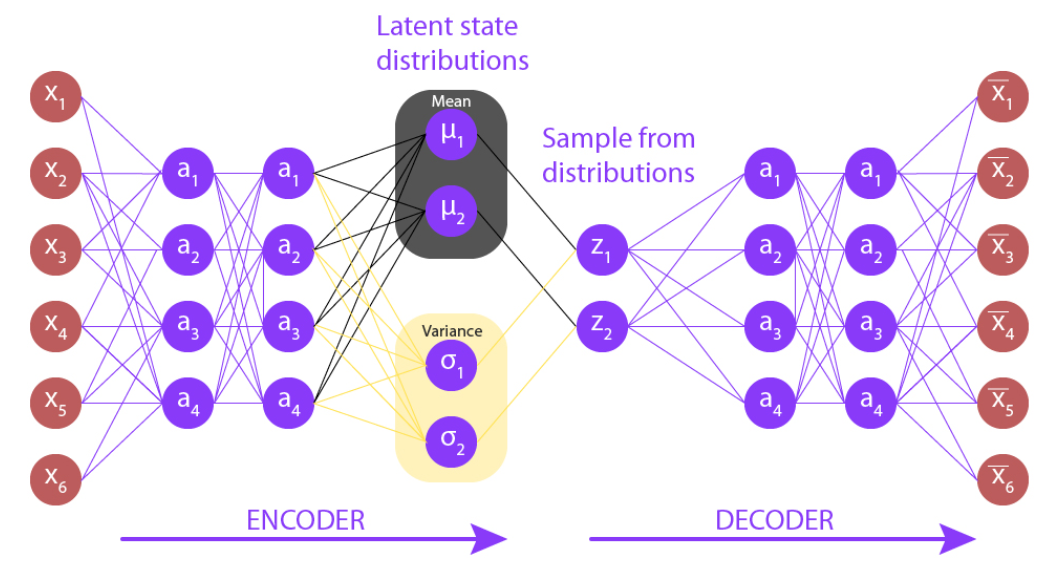

In [21]:
# ACTUAL MODEL(ENCODER + DECODER)
class DefectCVAE(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, latent_dim):
        super().__init__()
        self.node_dim   = node_dim
        
        self.encoder = EncoderPart(node_dim, edge_dim, u_dim, latent_dim)
        self.decoder = DecoderPart(latent_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, data):
        mu, log_var = self.encoder(data)
        
        if self.training:
            z = self.reparameterize(mu, log_var)
        else:
            z = mu

        out_decoder = self.decoder(z, data.bgv, data.pristine_x, data.pristine_e)
            
        return out_decoder, mu, log_var

# Test with first batch from loader
# for batch in full_train_loader:
the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for the_sample in sample_train_loader:

    MAX = the_sample.x.shape[0]

    # Test full model
    test_model = DefectCVAE(ENCODER_X_DIM, ENCODER_EDGE_DIM, ENCODER_U_DIM, LATENT_DIM)
    out, mu, log_var = test_model(the_sample)
    break

## Loss Function

In [22]:
class LossFN(nn.Module):
    def __init__(self, site_weight):
        super().__init__()

        # Weights
        self.count_weight = 1/50
        self.site_weight = torch.tensor(site_weight, dtype=torch.float)
        # self.specie_weight = torch.tensor(specie_weight, dtype=torch.float)
        # self.site_weight = torch.tensor(site_weight, dtype=torch.float)
        # self.specie_weight = specie_weight

        # Loss functions
        self.count_loss_fn = nn.MSELoss()

        

    def forward(self, model_output, mu, log_var, y, ref_mask, device):

        y = y.to(device)
        ref_mask = ref_mask.to(device)

        # =================
        # Predictions 
        # =================

        # pred_num_vacs = model_output[0].to(device)
        # pred_num_defects = model_output[0].to(device)
        # pred_site_logits = model_output[1].to(device) # [144,2]
        # pred_type_logits = model_output[2].to(device) # [144,2]
        model_output = model_output.to(device)
        probs = torch.softmax(model_output, dim=-1)        # [num_sites, 3]
        prob_defective = 1.0 - probs[:, 0]                   # P(not "normal") per site
        soft_pred_count = prob_defective.sum()                
        # output_labels = logits_manipulation(model_output)
        # pred_num_defects = (output_labels != 0).sum().float()
        mu = mu.to(device)
        log_var = log_var.to(device)

        # ==================        
        # Targets
        # ==================

        target_labels = Zs_and_labels(ref_mask, atomic_numbers=y)
        target_num_defects = ((target_labels != 0).sum().float().view_as(soft_pred_count))
        # target_sites = (target_labels != 0).long() # [144]
        # target_defective_indices = torch.where(target_sites == 1)[0]

        # clean_species_targets = target_labels - 1 
        # target_types = clean_species_targets[target_defective_indices].to(device) 


        # =====================
        # Defects Count Loss
        # =====================
        
        defects_num_loss = self.count_loss_fn(soft_pred_count, target_num_defects)
        weighted_defects_num_loss = (self.count_weight * defects_num_loss)

        # =====================
        # Site Loss
        # =====================

        site_loss = F.cross_entropy(
            model_output,
            target_labels,
            weight=self.site_weight.to(device)
        )
        # site_loss = self.site_loss_fn(pred_site_logits, target_sites.unsqueeze(1))
        # site_loss = F.binary_cross_entropy_with_logits(pred_site_logits, target_sites.unsqueeze(1))
        # site_loss = self.site_ranking_loss(pred_site_logits,target_sites)
        
        # ======================
        # Species Loss
        # ======================

        # pred_types = pred_type_logits[target_defective_indices]
        # type_loss = F.cross_entropy(
        #     pred_types, 
        #     target_types, 
        #     weight=self.specie_weight.to(device)
        # )
        

        # ======================
        # KL Loss
        # ======================
        kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()) 
        kl_per_dim = torch.clamp(kl_per_dim, min=0.25)
        kl_loss = kl_per_dim.sum(dim=1).mean()

        # kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

        # ======================
        # Total Loss
        # ======================

        # total = weighted_defects_num_loss + site_loss + type_loss + (beta * kl_loss)
        
        return weighted_defects_num_loss, site_loss, kl_loss

# Test loss function
# for a_batch in full_train_loader:
the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


for a_batch in sample_train_loader:
    test_model = DefectCVAE(ENCODER_X_DIM, ENCODER_EDGE_DIM, ENCODER_U_DIM, LATENT_DIM)
    out, mu, log_var = test_model(a_batch)

    the_loss_fn = LossFN(SAMPLE_WEIGHTS)
    count_loss, site_loss, kl_loss = the_loss_fn(out, mu, log_var, a_batch.y, a_batch.mask, the_device)
    print(count_loss, site_loss, kl_loss)
    print(f"Total loss: {count_loss + site_loss + (1e-3 * kl_loss)}")
    # print(f"total: {a}, defects_count_loss: {e}, species_loss: {c}, kl_loss: {d}")

    break

tensor(195.5893, device='cuda:0', grad_fn=<MulBackward0>) tensor(1.1587, device='cuda:0', grad_fn=<NllLossBackward0>) tensor(8., device='cuda:0', grad_fn=<MeanBackward0>)
Total loss: 196.75596618652344


## Training and Validating

In [23]:
# Training Function
def train_model(model, train_loader, cvae_loss, current_beta, device, optimizer):
    # Set the model in training mode
    model.train()

    # To track the losses
    losses = [[],[],[],[],]

    for batch in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        # Output of the model
        batch = batch.to(device)
        out_train, mu, log_var = model(batch)
        
        # NUM_SITES = batch.x.shape[0]
        # gen_structure_tensor = recon.view((NUM_SITES, (1 + MASK_DIM)))

        # The loss (pass batch.mask and configured weight_penalty)
        count_loss, site_loss, kl_loss = cvae_loss(
            out_train, mu, log_var,batch.y, 
            batch.mask, device
            )

        # L1 regularization
        # l1_norm = sum(p.abs().sum() for p in model.parameters())
        # type_loss += 0.01 * l1_norm
        # site_loss += 0.02 * l1_norm

        # L2 regularization
        # l2_norm = sum(p.pow(2).sum() for p in model.parameters())
        # type_loss += 0.01 * l2_norm

        # modify the total loss to feature the new type loss
        total_loss = count_loss + site_loss + (current_beta * kl_loss)

        out_train_loss = [total_loss, count_loss, site_loss, kl_loss]
        
        total_loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        for i, j in enumerate(out_train_loss):
            losses[i].append(j.item() *batch.num_graphs)
        

    n = len(train_loader)
    t_losses = {
        "Total_loss": sum(losses[0])/n, 
        "Defects_Count_loss": sum(losses[1])/n,
        "Defect_Site_loss": sum(losses[2])/n,
        # "Defect_Type_loss": sum(losses[3])/n, 
        "KL_loss": sum(losses[3])/n, 
    }

    return t_losses

def validate_model(model, val_loader, cvae_loss, current_beta, device):
    # Model in evaluation mode
    model.eval()
    
    # t_loss, c_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0
    losses = [[],[],[],[],]

    with torch.no_grad():
        for batch in tqdm(val_loader, leave=False):
            batch = batch.to(device)
            out_val, mu, log_var = model(batch)
            # NUM_SITES = batch.x.shape[0]
            # recon = recon.view((NUM_SITES,(1 + MASK_DIM)))

            # out_val_loss = cvae_loss(out_val, mu, log_var, batch.y, batch.mask, current_beta, device)
            count_loss, site_loss, kl_loss = cvae_loss(
                out_val, mu, log_var,batch.y, 
                batch.mask, device
                )

            total_loss = count_loss + site_loss + (current_beta * kl_loss)

            out_val_loss = [total_loss, count_loss, site_loss, kl_loss]
            
            if torch.isnan(total_loss).any():
                print("Found an NaN value")
                break

            for i, j in enumerate(out_val_loss):
                losses[i].append(j.item() * batch.num_graphs)

        n = len(val_loader)# .dataset)
        v_losses = {
            "Total_loss": sum(losses[0])/n, 
            "Defects_Count_loss": sum(losses[1])/n,
            "Defect_Site_loss": sum(losses[2])/n,
            # "Defect_Type_loss": sum(losses[3])/n, 
            "KL_loss": sum(losses[3])/n, 
            }

        return v_losses



# Loaders for Full Dataset
# train_loader = full_train_loader 
# val_loader = full_val_loader 

# Loaders for Sample Dataset
train_loader = sample_train_loader 
val_loader = sample_val_loader 

# Parameters for training model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DefectCVAE(ENCODER_X_DIM, ENCODER_EDGE_DIM, ENCODER_U_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
cvae_loss = LossFN(SAMPLE_WEIGHTS) # [0], SAMPLE_WEIGHTS[1], SAMPLE_WEIGHTS[2])

EPOCHS = 20
beta   = 1e-3

train_metrics, val_metrics = [], []

def get_beta(epoch, warmup_epochs=5, ramp_epochs=10, beta_max=1e-3):
    if epoch <= warmup_epochs:
        return 0.0
    ramp_progress = min(1.0, (epoch - warmup_epochs) / ramp_epochs)
    return beta_max * ramp_progress


for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch:4d}")
    # Train
    # current_beta = beta * min(1.0, epoch / EPOCHS)
    current_beta = get_beta(epoch, warmup_epochs=5, ramp_epochs=10, beta_max=1e-3)

    t_losses = train_model(model,train_loader, cvae_loss, current_beta, device, optimizer)

    # Validate
    val_losses = validate_model(model, val_loader, cvae_loss, current_beta, device)
    scheduler.step()

    # Store and print metrics
    train_metrics.append(t_losses)
    val_metrics.append(val_losses)

    print("TRAINING LOSSES")

    train_loss_types = list(t_losses.keys())
    train_loss_values = list(t_losses.values())

    for i, j in zip(train_loss_types, train_loss_values):
        print(f"\t{i} : {j:.4f}")

    print("\nVALIDATING LOSSES")

    val_loss_types = list(val_losses.keys())
    val_loss_values = list(val_losses.values())

    for i, j in zip(val_loss_types, val_loss_values):
        print(f"\t{i} : {j:.4f}")
    

Epoch    1


  0%|          | 0/1600 [00:00<?, ?it/s]

TRAINING LOSSES
	Total_loss : 4.7677
	Defects_Count_loss : 2.6974
	Defect_Site_loss : 2.0703
	KL_loss : 752.2250

VALIDATING LOSSES
	Total_loss : 2.0491
	Defects_Count_loss : 0.0334
	Defect_Site_loss : 2.0157
	KL_loss : 1046.8261
Epoch    2


TRAINING LOSSES
	Total_loss : 2.0613
	Defects_Count_loss : 0.0548
	Defect_Site_loss : 2.0065
	KL_loss : 1116.2403

VALIDATING LOSSES
	Total_loss : 2.0493
	Defects_Count_loss : 0.0248
	Defect_Site_loss : 2.0245
	KL_loss : 1004.6300
Epoch    3


TRAINING LOSSES
	Total_loss : 2.0522
	Defects_Count_loss : 0.0485
	Defect_Site_loss : 2.0037
	KL_loss : 954.8730

VALIDATING LOSSES
	Total_loss : 2.0463
	Defects_Count_loss : 0.0318
	Defect_Site_loss : 2.0145
	KL_loss : 841.9497
Epoch    4


...

TRAINING LOSSES
	Total_loss : 2.0587
	Defects_Count_loss : 0.0451
	Defect_Site_loss : 2.0007
	KL_loss : 12.8847

VALIDATING LOSSES
	Total_loss : 2.0688
	Defects_Count_loss : 0.0121
	Defect_Site_loss : 2.0444
	KL_loss : 12.3515
Epoch   17


TRAINING LOSSES
	Total_loss : 2.0593
	Defects_Count_loss : 0.0456
	Defect_Site_loss : 2.0008
	KL_loss : 12.9240

VALIDATING LOSSES
	Total_loss : 2.0566
	Defects_Count_loss : 0.0350
	Defect_Site_loss : 2.0089
	KL_loss : 12.7326
Epoch   18


TRAINING LOSSES
	Total_loss : 2.0581
	Defects_Count_loss : 0.0447
	Defect_Site_loss : 2.0007
	KL_loss : 12.7297

VALIDATING LOSSES
	Total_loss : 2.0568
	Defects_Count_loss : 0.0501
	Defect_Site_loss : 1.9940
	KL_loss : 12.6791
Epoch   19


TRAINING LOSSES
	Total_loss : 2.0581
	Defects_Count_loss : 0.0450
	Defect_Site_loss : 2.0003
	KL_loss : 12.7226

VALIDATING LOSSES
	Total_loss : 2.0569
	Defects_Count_loss : 0.0306
	Defect_Site_loss : 2.0136
	KL_loss : 12.6504
Epoch   20


TRAINING LOSSES
	Total_loss : 2.0579
	Defects_Count_loss : 0.0447
	Defect_Site_loss : 2.0005
	KL_loss : 12.6461

VALIDATING LOSSES
	Total_loss : 2.0575
	Defects_Count_loss : 0.0280
	Defect_Site_loss : 2.0171
	KL_loss : 12.4228


In [24]:
training_losses = []
validating_losses = []

valuess = list(train_metrics[0].keys())   

for i in valuess:
    the_train_loss = []
    for j in range(len(train_metrics)):
        the_train_loss.append(train_metrics[j][i])
    training_losses.append(the_train_loss)

    the_val_loss = []
    for j in range(len(val_metrics)):
        the_val_loss.append(val_metrics[j][i])
    validating_losses.append(the_val_loss)

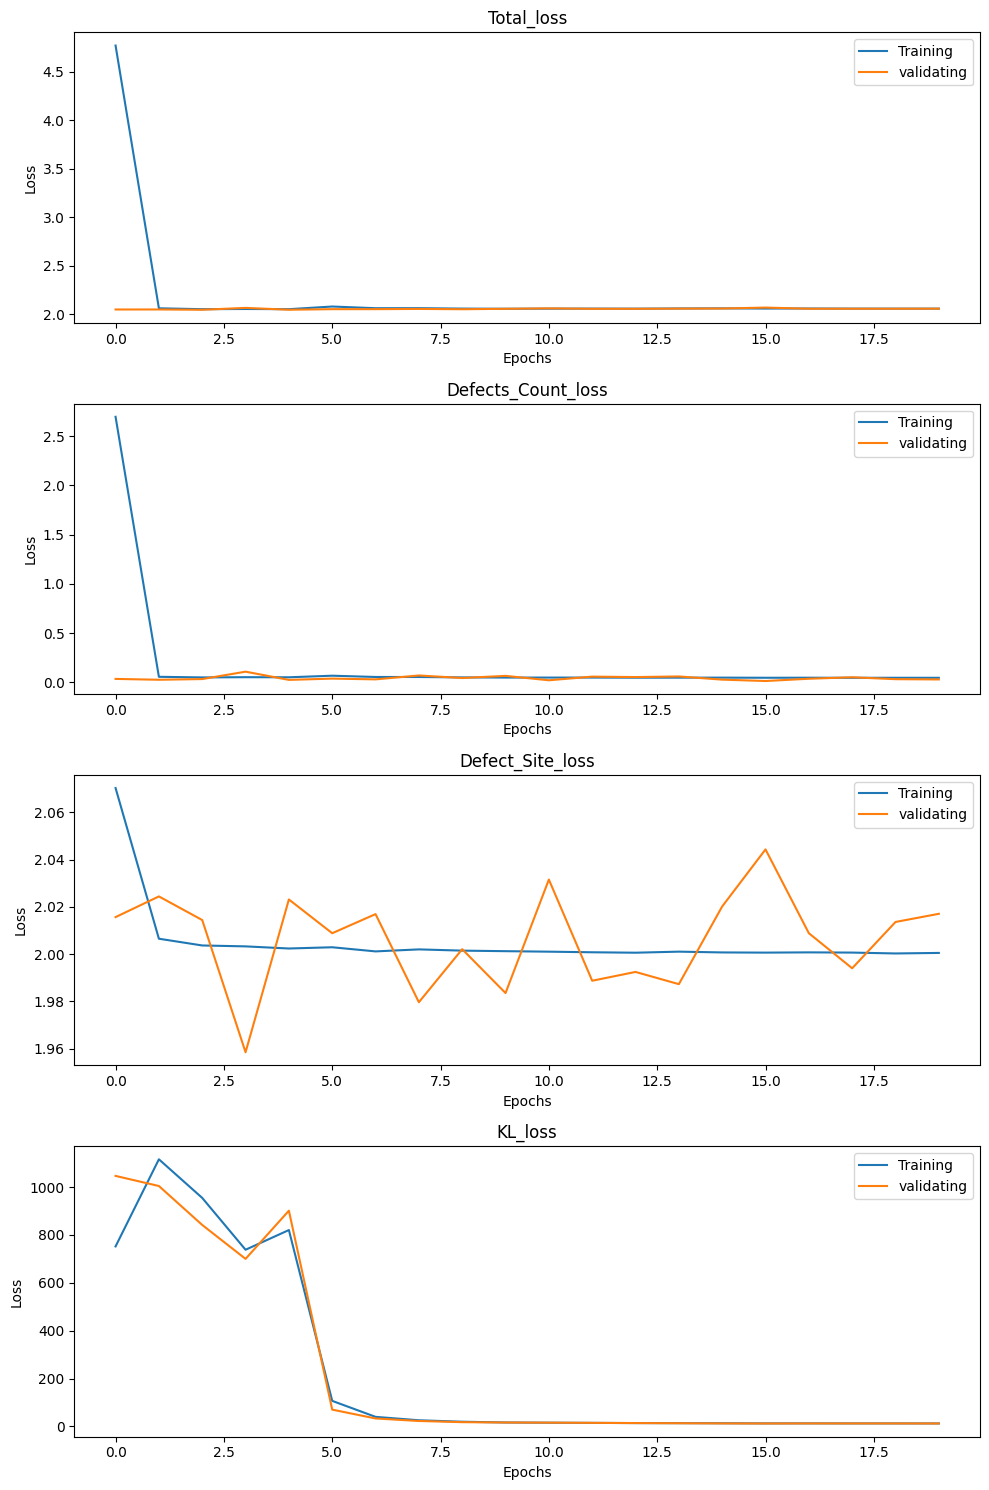

In [25]:
titles = list(train_metrics[0].keys())   

variabless = len(titles)

fig, axes = plt.subplots(variabless, 1, figsize=(10, 15))

axes_flat = axes.flatten()

for title, trains, vals, ax in zip(titles, training_losses, validating_losses, axes_flat):
    ax.plot(trains, label='Training')
    ax.plot(vals, label='validating')
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

## Diagnose Model

Is the model using all the losses instead of focusing on one attriibute's loss?

In [27]:
print(model.decoder.out_mlp[-1].bias)

Parameter containing:
tensor([ 0.1817, -0.3765, -0.2214], device='cuda:0', requires_grad=True)


In [28]:
@torch.no_grad()
def diagnose_loss_scales(model, loader, cvae_loss, device, n_batches=100):
    model.eval()

    records = {
        "total_loss": [], "defects_num_loss": [],
        "site_loss": [], "kl_loss": []
    }

    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        batch = batch.to(device)
        out, mu, log_var = model(batch)
        # beta=1.0 here just so we can see the RAW kl magnitude, unscaled
        count_loss, site_loss, kl_loss = cvae_loss(out, mu, log_var, batch.y, batch.mask, device=device)
        total_loss = count_loss +site_loss + (1.0 * kl_loss)

        records["total_loss"].append(total_loss.item())
        records["defects_num_loss"].append(count_loss.item())
        records["site_loss"].append(site_loss.item())
        # records["type_loss"].append(type_loss.item())
        records["kl_loss"].append(kl_loss.item())

    print(f"{'Loss term':25s} {'mean':>10s} {'std':>10s} {'min':>10s} {'max':>10s}")
    for k, v in records.items():
        v = np.array(v)
        print(f"{k:25s} {v.mean():10.4f} {v.std():10.4f} {v.min():10.4f} {v.max():10.4f}")

    return records

raw_scales = diagnose_loss_scales(model, train_loader, cvae_loss, device)

Loss term                       mean        std        min        max
total_loss                   14.2881     1.1325    13.1075    17.3385
defects_num_loss              0.0258     0.0151     0.0064     0.0522
site_loss                     2.0468     0.2382     1.4658     2.2203
kl_loss                      12.2155     1.3368    10.8970    15.8195


In [29]:
@torch.no_grad()
def diagnose_z_sensitivity_fixed_sample(model, sample, device, n_draws=10):
    model.eval()
    sample = sample.to(device)
    mu, log_var = model.encoder(sample)
    std = torch.exp(0.5 * log_var)

    counts, site_logits_list, type_logits_list = [], [], []
    for _ in range(n_draws):
        z = mu + torch.randn_like(std) * std
        out_decoder = model.decoder(z, sample.bgv, sample.pristine_x, sample.pristine_e)
        output_labels = decode_structure(out_decoder)
        pred_num_defects = (output_labels != 0).sum().float()
        counts.append(pred_num_defects.item())
        site_logits_list.append(out_decoder.squeeze(-1).cpu())
        # type_logits_list.append(out_decoder[2].cpu())

    print("Count predictions after running decoder on the same encoder output:\n", counts)
    print(f"count std: {torch.tensor(counts).std().item():.4f}")

    site_stack = torch.stack(site_logits_list)
    print(f"\nsite_logits mean per-site std across z draws: {site_stack.std(dim=0).mean().item():.5f}")

    for i in range(1, n_draws):
        cos = torch.nn.functional.cosine_similarity(
            site_stack[0].flatten(), site_stack[i].flatten(), dim=0
        )
        print(f"  site_logits draw 0 vs draw {i}: cosine sim = {cos.item():.4f}")

    return counts, site_stack

# pick ONE sample and keep it fixed
fixed_sample = next(iter(sample_train_loader))
diagnose_z_sensitivity_fixed_sample(model, fixed_sample, device, n_draws=10)

Count predictions after running decoder on the same encoder output:
 [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0]
count std: 0.0000

site_logits mean per-site std across z draws: 0.01201
  site_logits draw 0 vs draw 1: cosine sim = 1.0000
  site_logits draw 0 vs draw 2: cosine sim = 1.0000
  site_logits draw 0 vs draw 3: cosine sim = 1.0000
  site_logits draw 0 vs draw 4: cosine sim = 1.0000
  site_logits draw 0 vs draw 5: cosine sim = 1.0000
  site_logits draw 0 vs draw 6: cosine sim = 1.0000
  site_logits draw 0 vs draw 7: cosine sim = 1.0000
  site_logits draw 0 vs draw 8: cosine sim = 1.0000
  site_logits draw 0 vs draw 9: cosine sim = 1.0000


([13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0],
 tensor([[[ 0.6659, -2.0845, -2.0524],
          [ 0.6676, -2.1162, -2.0843],
          [ 0.6714, -2.1876, -2.1562],
          ...,
          [ 0.6727, -2.2134, -2.1822],
          [ 0.6712, -2.1836, -2.1522],
          [ 0.6759, -2.2795, -2.2487]],
 
         [[ 0.6646, -2.0603, -2.0279],
          [ 0.6667, -2.0988, -2.0667],
          [ 0.6707, -2.1754, -2.1439],
          ...,
          [ 0.6725, -2.2092, -2.1779],
          [ 0.6710, -2.1796, -2.1482],
          [ 0.6758, -2.2764, -2.2456]],
 
         [[ 0.6664, -2.0924, -2.0603],
          [ 0.6681, -2.1250, -2.0931],
          [ 0.6718, -2.1968, -2.1655],
          ...,
          [ 0.6732, -2.2235, -2.1924],
          [ 0.6717, -2.1938, -2.1625],
          [ 0.6764, -2.2896, -2.2589]],
 
         ...,
 
         [[ 0.6648, -2.0648, -2.0325],
          [ 0.6669, -2.1032, -2.0711],
          [ 0.6709, -2.1796, -2.1482],
          ...,
          [ 0.6727, -2.2135, -2.1

In [30]:
@torch.no_grad()
def check_posterior_prior_mismatch(model, loader, device, n_batches=200):
    model.eval()
    all_mu, all_logvar = [], []

    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        batch = batch.to(device)
        mu, log_var = model.encoder(batch)
        all_mu.append(mu.cpu())
        all_logvar.append(log_var.cpu())

    all_mu = torch.cat(all_mu, dim=0)          # [n_samples, latent_dim]
    all_logvar = torch.cat(all_logvar, dim=0)

    print(f"mu magnitude:  mean |mu| = {all_mu.abs().mean().item():.4f}   (N(0,1) prior expects ~0)")
    print(f"mu per-dim std across SAMPLES = {all_mu.std(dim=0).mean().item():.4f}   (want > 0: means different samples get different mu)")
    print(f"posterior std (from log_var) = {torch.exp(0.5*all_logvar).mean().item():.4f}   (N(0,1) prior expects ~1)")
    print()
    print("If mu magnitude is large and posterior std is small, the aggregate posterior")
    print("is far from N(0,1) -- sampling z~N(0,1) at generation time is out-of-distribution for the decoder.")

    return all_mu, all_logvar

all_mu, all_logvar = check_posterior_prior_mismatch(model, sample_train_loader, device)

mu magnitude:  mean |mu| = 0.2200   (N(0,1) prior expects ~0)
mu per-dim std across SAMPLES = 0.2165   (want > 0: means different samples get different mu)
posterior std (from log_var) = 0.7073   (N(0,1) prior expects ~1)

If mu magnitude is large and posterior std is small, the aggregate posterior
is far from N(0,1) -- sampling z~N(0,1) at generation time is out-of-distribution for the decoder.


In [31]:
@torch.no_grad()
def diagnose_across_samples(model, loader, device, n_samples=6):
    model.eval()
    site_logits_list = []
    mus = []

    it = iter(loader)
    for i in range(n_samples):
        batch = next(it).to(device)
        mu, log_var = model.encoder(batch)
        mus.append(mu.cpu())

        out_decoder = model.decoder(
            mu, batch.bgv, batch.pristine_x, batch.pristine_e
        )
        site_logits_list.append(out_decoder.squeeze(1).cpu())

    print("Pairwise mu distance across DIFFERENT real samples:")
    for i in range(1, n_samples):
        dist = (mus[0] - mus[i]).norm().item()
        print(f"  sample 0 vs sample {i}: ||mu diff|| = {dist:.4f}")

    print("\nPairwise site-logit cosine similarity across DIFFERENT real samples:")
    for i in range(1, n_samples):
        # only meaningful if same material / same num sites
        if site_logits_list[0].shape == site_logits_list[i].shape:
            cos = torch.nn.functional.cosine_similarity(site_logits_list[0].flatten(), site_logits_list[i].flatten(), dim=0)
            print(f"  sample 0 vs sample {i}: {cos.item():.4f}")
        else:
            print(f"  sample 0 vs sample {i}: different material/size, skipped")

diagnose_across_samples(model, train_loader, device)

Pairwise mu distance across DIFFERENT real samples:
  sample 0 vs sample 1: ||mu diff|| = 0.0039
  sample 0 vs sample 2: ||mu diff|| = 3.9558
  sample 0 vs sample 3: ||mu diff|| = 0.3235
  sample 0 vs sample 4: ||mu diff|| = 3.8118
  sample 0 vs sample 5: ||mu diff|| = 1.7434

Pairwise site-logit cosine similarity across DIFFERENT real samples:
  sample 0 vs sample 1: different material/size, skipped
  sample 0 vs sample 2: 0.9979
  sample 0 vs sample 3: different material/size, skipped
  sample 0 vs sample 4: 0.9979
  sample 0 vs sample 5: 0.9997


In [32]:
@torch.no_grad()
def diagnose_z_ablation(model, loader, device, n_batches=20):
    model.eval()
    diffs_site, diffs_type, diffs_count = [], [], []

    it = iter(loader)
    for i in range(n_batches):
        try:
            batch = next(it).to(device)
        except StopIteration:
            break

        mu, log_var = model.encoder(batch)

        out_real = model.decoder(mu, batch.bgv, batch.pristine_x, batch.pristine_e)
        out_zero = model.decoder(torch.zeros_like(mu), batch.bgv, batch.pristine_x, batch.pristine_e)

        # how different are the outputs with real z vs no z at all?
        out_real_counts= (logits_manipulation(out_real) != 0).sum().float()
        out_zero_counts = (logits_manipulation(out_zero) != 0).sum().float()

        diffs_count.append((out_real_counts - out_zero_counts).abs().item())

        diffs_site.append(
            torch.nn.functional.cosine_similarity(
                out_real.flatten(), out_zero.flatten(), dim=0
            ).item()
        )
        # diffs_type.append(
        #     torch.nn.functional.cosine_similarity(
        #         out_real[2].flatten(), out_zero[2].flatten(), dim=0
        #     ).item()
        # )

    print(f"count |real - z=0| mean: {sum(diffs_count)/len(diffs_count):.4f}")
    print(f"site_logits cosine sim (real z vs z=0): {sum(diffs_site)/len(diffs_site):.4f}  (near 1.0 = z is basically irrelevant)")
    # print(f"type_logits cosine sim (real z vs z=0): {sum(diffs_type)/len(diffs_type):.4f}  (near 1.0 = z is basically irrelevant)")

diagnose_z_ablation(model, sample_train_loader, device)

count |real - z=0| mean: 0.0000
site_logits cosine sim (real z vs z=0): 0.9997  (near 1.0 = z is basically irrelevant)


In [33]:
@torch.no_grad()
def check_decision_margins(model, sample, device):
    model.eval()
    sample = sample.to(device)
    mu, log_var = model.encoder(sample)
    out_decoder = model.decoder(mu, sample.bgv, sample.pristine_x, sample.pristine_e)
    probs = torch.softmax(out_decoder, dim=-1)  # [num_sites, 3]

    p_normal = probs[:, 0]
    p_defective = 1.0 - p_normal

    print(f"P(normal) across sites — mean: {p_normal.mean():.4f}, min: {p_normal.min():.4f}")
    print(f"Top 10 sites by P(defective): {torch.topk(p_defective, 10).values}")

check_decision_margins(model, fixed_sample, device)

P(normal) across sites — mean: 0.8991, min: 0.8800
Top 10 sites by P(defective): tensor([0.1200, 0.1163, 0.1162, 0.1119, 0.1117, 0.1109, 0.1104, 0.1089, 0.1075,
        0.1075], device='cuda:0')


In [34]:
@torch.no_grad()
def trace_decoder_collapse(model, sample, device, n_z_draws=3):
    model.eval()
    sample = sample.to(device)

    # print(sample.device)
    mu, log_var = model.encoder(sample)
    std = torch.exp(0.5 * log_var)

    decoder = model.decoder

    for draw in range(n_z_draws):
        z = mu + torch.randn_like(std) * std

        for_u = decoder.bgv_mlp(sample.bgv.unsqueeze(0))
        for_x = decoder.pristine_mlp(sample.pristine_x)

        site_ids = torch.arange(sample.pristine_x.size(0), device=device)
        for_x_with_id = for_x + decoder.site_id_embedding(site_ids)

        print(f"--- z draw {draw} ---")
        print(f"for_x (post pristine_mlp) per-site std: {for_x.std(dim=0).mean().item():.5f}")
        print(f"site_id_embedding alone, per-site std:   {decoder.site_id_embedding(site_ids).std(dim=0).mean().item():.5f}")
        print(f"for_x + site_id, per-site std:            {for_x_with_id.std(dim=0).mean().item():.5f}")

        # now run it through the blocks (eval mode => no dropout applied)
        cur_u, cur_x = for_u, for_x_with_id
        for i, block in enumerate(decoder.blocks):
            new_u, new_x = block(z, cur_u, cur_x, sample.pristine_e)
            cur_u = new_u + cur_u
            cur_x = new_x + cur_x
            print(f"  after block {i}: new_x per-site std = {new_x.std(dim=0).mean().item():.5f}, "
                  f"cumulative for_x per-site std = {cur_x.std(dim=0).mean().item():.5f}")

        comb = torch.cat([cur_u.repeat(cur_x.size(0), 1), cur_x], dim=1)
        print(f"final comb per-site std: {comb.std(dim=0).mean().item():.5f}")
        print()

trace_decoder_collapse(model, fixed_sample, device)

--- z draw 0 ---
for_x (post pristine_mlp) per-site std: 0.10898
site_id_embedding alone, per-site std:   0.04965
for_x + site_id, per-site std:            0.12797
  after block 0: new_x per-site std = 0.03128, cumulative for_x per-site std = 0.11706
final comb per-site std: 0.05853

--- z draw 1 ---
for_x (post pristine_mlp) per-site std: 0.10898
site_id_embedding alone, per-site std:   0.04965
for_x + site_id, per-site std:            0.12797
  after block 0: new_x per-site std = 0.02855, cumulative for_x per-site std = 0.11550
final comb per-site std: 0.05775

--- z draw 2 ---
for_x (post pristine_mlp) per-site std: 0.10898
site_id_embedding alone, per-site std:   0.04965
for_x + site_id, per-site std:            0.12797
  after block 0: new_x per-site std = 0.02825, cumulative for_x per-site std = 0.11533
final comb per-site std: 0.05766



## Inverse Design

In [35]:
import gnn_models
import graphy_gnn

# Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# the_model = gnn_models.GNNModel1().to(device)
the_gnn_model = gnn_models.AI4matPart(26, 14, 6, embed_dim=32, num_blocks=3).to(device)
gnn_model_path = "Final_Dataset/gnn models/megnet_model.pth"
the_gnn_model.load_state_dict(torch.load(gnn_model_path))


<All keys matched successfully>

In [36]:
def gen_tensor(model, reference_structure, target_band_gap, device = "cpu"):
    model.eval()
    model.to(device)

    with torch.no_grad():
        
            
        the_z = torch.randn(1, 32, device=device)
        the_condition = torch.tensor(target_band_gap, dtype=torch.float).unsqueeze(0).to(device=device)
        the_pristine_mask = torch.tensor(get_mask(reference_structure), dtype=torch.long)
        the_pristine_edges = torch.tensor(get_pristine_edges(reference_structure), dtype=torch.long)
        the_pristine_features = torch.tensor(get_pristine_nodes(reference_structure), dtype=torch.float)
        
    
        # Run decoder
        out_gen = model.decoder(the_z, the_condition, the_pristine_features, the_pristine_edges)
        # defective_tensors = defective_tensors.view((out_sites, (1 + self.mask_dim)))

    return (out_gen, the_pristine_mask)


def predict_bgv(the_model, device, original_structure, generated_structure, tbgv):

    # Prepare Generated Structure
    clean_defective_structure = full_defective_manipulation(generated_structure, original_structure, get_clean_defective=True)

    the_data = gnn_graphy(tbgv, clean_defective_structure, original_structure)

    # remove ref_idx 
    the_data.x = the_data.x[:, :-1]

    the_data = add_bond_batch([the_data])

    attempt = DataLoader(the_data, batch_size=1, shuffle=False)

    # Make prediction
    the_prediction, the_target = gnn_models.predict(the_model, attempt, device)
    print(f"Predicted Band Gap: {the_prediction[0]}")
    # print(f"Target Band Gap: {the_target[0]}")
    


comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

def test_from_df(the_material):

    sample_df = comb_df[comb_df["dataset_material"] == f"high_{the_material}"]
    
    choose_sample = random.randint(0,len(sample_df)-1)

    sample_row = sample_df.iloc[choose_sample]

    # Get required attributes from sample row
    sample_dataset_material = sample_row["dataset_material"]
    sample_id = sample_row["_id"]

    # Get defective structure
    clean_defective_path = f"original_dataset/{sample_dataset_material}/cifs/{sample_id}.cif"
    clean_defective_structure = Structure.from_file(clean_defective_path)

    # Get reference structure
    pristine_path = f"Final_Dataset/ref_cifs/{sample_dataset_material}.cif"
    pristine_structure = Structure.from_file(pristine_path)

    # Get Full Defective Structure
    full_defective_structure  = clean_defective_manipulation(clean_defective_structure, pristine_structure, get_full_defective=True)

    sample_bgv = sample_row["band_gap_value"]
    print(f"Target Band Gap  : {sample_bgv}\n")

    print("TARGET STRUCTURE")
    print(f"Structure Formula: {full_defective_structure.formula}")
    visualize_structure(full_defective_manipulation(full_defective_structure, pristine_structure, get_cloud=True))

    print("PREDICTED STRUCTURE")
    out_gen = gen_tensor(model, pristine_structure, sample_bgv, "cpu")
    generated_structure = gen_structure(pristine_structure, out_gen[1], out_gen[0])

    print(f"Structure Formula: {generated_structure.formula}")
    visualize_structure(full_defective_manipulation(generated_structure, pristine_structure, get_cloud=True))

    return pristine_structure, full_defective_structure, generated_structure, sample_bgv

Target Band Gap  : 0.7914999999999992

TARGET STRUCTURE
Structure Formula: X4 In67 Ga3 Se70


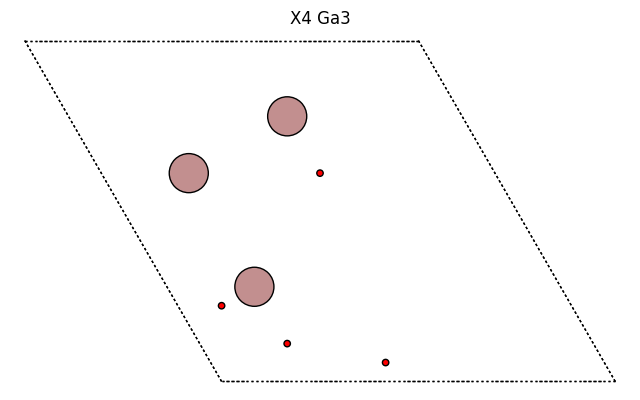

PREDICTED STRUCTURE
Structure Formula: In67 Ga5 Se65 S7


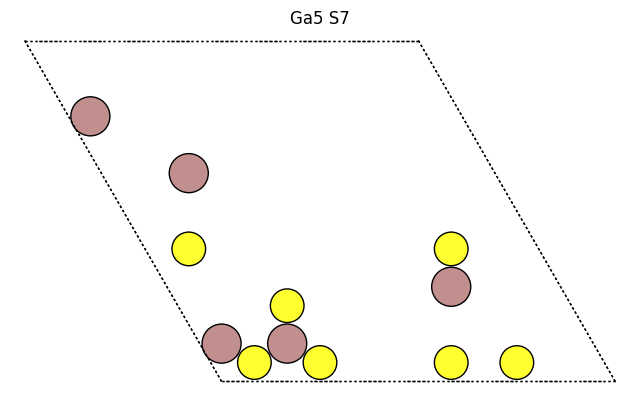


BAND GAP OF GENERATED STRUCTURE


Predicted Band Gap: -17.893177032470703


In [47]:
# uncomment a line with a material to generate a structure
# original_structure, target_structure, generated_structure, tbgv = test_from_df("GaSe")
original_structure, target_structure, generated_structure, tbgv = test_from_df("InSe")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("BN")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("P")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("WSe2")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("MoS2")

# the_cloud = get_cloud(generated_structure, original_structure)

print("\nBAND GAP OF GENERATED STRUCTURE")
predict_bgv(the_gnn_model, device, original_structure, generated_structure, tbgv)
